# The NCA Manifold

One neural cellular automaton whose per-cell update rule is **generated from a latent
vector**, so that a whole family of organisms lives in one continuous latent space.

Implements *Neural Cellular Automata Manifold* — Hernandez Ruiz, Vilalta &
Moreno-Noguer, CVPR 2021 ([arXiv:2006.12155](https://arxiv.org/abs/2006.12155)).

### The mechanism

A latent $e$ is pushed through a DNA decoder $D$ and a parameter predictor $P$:

$$\kappa(e) = P(D(e))$$

and $\kappa(e)$ **is** the weight tensor of the per-cell update network. It is computed
once per rollout — not per step, and not per cell. So each latent is a *different
cellular automaton*, not the same automaton given a different input.

Every organism grows from an **identical single-cell seed**. That is the whole point: if
the seeds are identical and the weights are identical except for $z$, then the latent is
the only thing that can possibly explain why one grows a lizard and another grows a
flower.

### Two deliberate deviations from the paper

1. **Weights are a residual on a learned base rule**, with the predictor zero-initialised.
   Training therefore starts from one well-conditioned shared rule rather than from noise.
2. **No InstanceNorm.** It reduces over all of $H \times W$, which destroys the locality
   that makes an NCA an NCA, and it cannot be expressed in a WebGPU shader. A per-cell
   channel RMS norm is available behind `CFG.rms_norm` instead.

### Using it for your own targets

Everything below is `K`-agnostic — `K` is inferred from however many targets you supply.
Change **one line**, in the *Choose your targets* cell:

```python
TARGETS, NAMES = targets_from_shapes(CFG)              # synthetic, fast, the default
TARGETS, NAMES = targets_from_folder("./my_pngs", CFG) # any folder of images
TARGETS, NAMES = targets_from_emoji(["🦎", "🌸"], CFG)  # rendered glyphs
```

Then run the notebook top to bottom. The acceptance test is the **shuffle-z ablation**
near the end: rolling the latents by one must make the loss dramatically worse. If
shuffling is cheap, the latent is decoration and there is no manifold.

## Setup

In [1]:
import copy
import glob
import math
import os
import time
import unicodedata
from dataclasses import asdict, dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Image as IPyImage
from IPython.display import clear_output, display
from PIL import Image, ImageDraw, ImageFont

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## recessive chart furniture; the data should be the only thing with weight
INK, INK_MUTED, GRIDLINE, SERIES = "#3f3f46", "#a1a1aa", "#e4e4e7", "#2f6f9f"
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 10, "font.size": 9})

print(f"torch {torch.__version__} | device {DEVICE}")

torch 2.11.0+cu126 | device cuda


## Configuration

Every constant lives here. Nothing below reads a hard-coded number, so a change here
propagates through the model, the targets and the figures.

Two flags are worth knowing about:

- **`rms_norm`** — per-cell channel normalisation. Local, unlike the paper's InstanceNorm.
  Off by default.
- **`learn_leak`** — the Euler timestep $\exp(\rho)$ is learnable by default, but in
  practice it never moves off its initialisation: it is degenerate with $\lVert W_2\rVert$,
  which the network can rescale freely. Set this to `False` to freeze it and remove one
  moving part when you are debugging.

In [2]:
@dataclass
class Config:
    ## --- cell state ------------------------------------------------------
    channels: int = 16              ## 4 visible (RGBA) + 12 hidden
    grid: int = 40
    alive_threshold: float = 0.1
    fire_rate: float = 0.5          ## stochastic per-cell update, train AND eval

    ## --- update rule -----------------------------------------------------
    hidden: int = 128
    rms_norm: bool = False          ## per-cell channel RMS norm, NOT InstanceNorm
    leak_init: float = 0.1          ## Euler timestep
    learn_leak: bool = True         ## False freezes it (degenerate with ||W2||)

    ## --- the manifold ----------------------------------------------------
    latent_dim: int = 8
    dna_hidden: int = 64

    ## --- training --------------------------------------------------------
    epochs: int = 4000
    lr: float = 2e-3
    scalar_lr: float = 1e-4         ## scalars bypass gradient normalisation
    steps_min: int = 48
    steps_max: int = 64
    seed: int = 0
    log_every: int = 100

    ## --- io --------------------------------------------------------------
    out_dir: str = "outputs"
    ckpt_name: str = "manifold.pth"

    @property
    def perception(self) -> int:
        return 3 * self.channels    ## identity + sobel_x + sobel_y


CFG = Config()
os.makedirs(CFG.out_dir, exist_ok=True)
CFG

Config(channels=16, grid=40, alive_threshold=0.1, fire_rate=0.5, hidden=128, rms_norm=False, leak_init=0.1, learn_leak=True, latent_dim=8, dna_hidden=64, epochs=4000, lr=0.002, scalar_lr=0.0001, steps_min=48, steps_max=64, seed=0, log_every=100, out_dir='outputs', ckpt_name='manifold.pth')

## Rendering helpers

Used by every figure. An NCA state is RGBA, so it is composited over a checkerboard —
otherwise transparent regions and black regions look identical and you cannot tell a dead
cell from a dark one.

In [3]:
def _checkerboard(h, w, tile=2):
    yy, xx = np.mgrid[0:h, 0:w]
    return np.where(((yy // tile) + (xx // tile)) % 2 == 0, 0.74, 0.82)


def upscale(a, s=5):
    '''Nearest-neighbour zoom. A 40x40 organism is unreadable at native size.'''
    return np.kron(a, np.ones((s, s, 1))) if a.ndim == 3 else np.kron(a, np.ones((s, s)))


def composite(state_chw):
    '''(C,H,W) tensor -> (H,W,3) array, RGBA over a checkerboard so alpha is visible.'''
    rgba = state_chw[0:4].detach().clamp(0, 1).cpu().numpy()
    rgb, a = rgba[0:3].transpose(1, 2, 0), rgba[3][..., None]
    bg = _checkerboard(*rgb.shape[:2])[..., None]
    return np.clip(rgb * a + bg * (1 - a), 0, 1)


def tile_figure(images, ncols, titles=None, row_labels=None, suptitle=None,
                scale=5, tile_in=1.7, highlight=None, path=None):
    '''Lay out a list of (C,H,W) states row-major. `highlight` is a set of indices to ring.'''
    highlight = highlight or set()
    n = len(images)
    nrows = math.ceil(n / ncols)
    fig, ax = plt.subplots(nrows, ncols, squeeze=False,
                           figsize=(tile_in * ncols, tile_in * nrows + (0.8 if suptitle else 0)))
    for i in range(nrows * ncols):
        r, c = divmod(i, ncols)
        a = ax[r][c]
        a.set_xticks([])
        a.set_yticks([])
        if i >= n:
            a.axis("off")
            continue
        a.imshow(upscale(composite(images[i]), scale), interpolation="nearest")
        if titles and titles[i]:
            a.set_title(titles[i], fontsize=8, color="crimson" if i in highlight else INK)
        if i in highlight:
            for sp in a.spines.values():
                sp.set_edgecolor("crimson")
                sp.set_linewidth(2)
        if row_labels and c == 0 and r < len(row_labels):
            a.set_ylabel(row_labels[r], fontsize=8, color=INK)
    if suptitle:
        fig.suptitle(suptitle, fontsize=10, color=INK)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=110, bbox_inches="tight")
        print(f"saved {path}")
    plt.show()
    return fig

## Targets — the pluggable part

Three loaders, one contract. Each returns:

- a float tensor of shape `(K, 4, grid, grid)` in `[0, 1]`, and
- a list of `K` names.

All three **premultiply RGB by alpha**, so colour only exists where the organism does.
The model's loss compares its first four channels directly against this tensor, so
anything that satisfies the contract is a valid target set.

| loader | source |
|---|---|
| `targets_from_shapes()` | four synthetic shapes — the default, trains in minutes |
| `targets_from_folder(path)` | every image in a directory, one latent each |
| `targets_from_emoji([...])` | glyphs rendered with a colour emoji font |

File-based targets are cropped to their visible content and re-centred, so images of
different sizes and framings end up comparable in scale.

In [4]:
IMAGE_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".bmp", ".gif")

EMOJI_FONTS = [
    r"C:\Windows\Fonts\seguiemj.ttf",
    "/System/Library/Fonts/Apple Color Emoji.ttc",
    "/usr/share/fonts/truetype/noto/NotoColorEmoji.ttf",
]


def _fit_rgba(img, grid, fill=0.85):
    '''Crop to visible content, then centre on a grid x grid transparent canvas.'''
    img = img.convert("RGBA")
    bbox = img.getchannel("A").getbbox()
    if bbox is not None:
        img = img.crop(bbox)
    side = max(img.size)
    square = Image.new("RGBA", (side, side), (0, 0, 0, 0))
    square.paste(img, ((side - img.width) // 2, (side - img.height) // 2))
    inner = max(1, int(round(grid * fill)))
    canvas = Image.new("RGBA", (grid, grid), (0, 0, 0, 0))
    off = (grid - inner) // 2
    canvas.paste(square.resize((inner, inner), Image.LANCZOS), (off, off))
    return canvas


def _to_target(img, grid):
    arr = np.asarray(_fit_rgba(img, grid), dtype=np.float32) / 255.0
    t = torch.from_numpy(arr).permute(2, 0, 1)     ## (4, grid, grid)
    t[:3] *= t[3:4]                                ## premultiply
    return t


def targets_from_shapes(cfg=CFG):
    '''Four maximally distinct shapes. Distinct on purpose: latent interpolation should
    be unmistakable rather than something you have to squint at.'''
    g = cfg.grid
    yy, xx = torch.meshgrid(torch.arange(g), torch.arange(g), indexing="ij")
    c = (g - 1) / 2.0
    dy, dx = yy - c, xx - c
    r = 0.225 * g                                   ## 9.0 at the default grid of 40

    circle = (dy**2 + dx**2).sqrt() <= r
    square = (dy.abs() <= r * 0.85) & (dx.abs() <= r * 0.85)
    tri = (dy <= r * 0.9) & (dy >= -r * 0.9) & (dx.abs() <= (dy + r * 0.9) * 0.55)
    plus = ((dy.abs() <= r * 0.32) & (dx.abs() <= r)) | ((dx.abs() <= r * 0.32) & (dy.abs() <= r))

    specs = [
        (circle, (0.90, 0.20, 0.20), "red circle"),
        (square, (0.20, 0.35, 0.90), "blue square"),
        (tri, (0.20, 0.75, 0.30), "green triangle"),
        (plus, (0.95, 0.80, 0.15), "yellow plus"),
    ]
    out = torch.zeros(len(specs), 4, g, g)
    names = []
    for i, (mask, rgb, name) in enumerate(specs):
        m = mask.float()
        for ch in range(3):
            out[i, ch] = rgb[ch] * m
        out[i, 3] = m
        names.append(name)
    return out, names


def targets_from_folder(path, cfg=CFG, limit=None):
    '''One latent per image file. Sorted by filename, so the latent order is stable.'''
    files = sorted(p for p in glob.glob(os.path.join(path, "*"))
                   if p.lower().endswith(IMAGE_EXTS))
    if not files:
        raise FileNotFoundError(
            f"no images ({', '.join(IMAGE_EXTS)}) found in {os.path.abspath(path)!r}")
    files = files[:limit] if limit else files

    tensors, names, opaque = [], [], []
    for p in files:
        img = Image.open(p).convert("RGBA")
        if np.asarray(img)[..., 3].min() == 255:
            opaque.append(os.path.basename(p))
        tensors.append(_to_target(img, cfg.grid))
        names.append(os.path.splitext(os.path.basename(p))[0])

    if opaque:
        shown = ", ".join(opaque[:4]) + (" ..." if len(opaque) > 4 else "")
        print(f"note: {len(opaque)} of {len(files)} image(s) are fully opaque, so the target "
              f"is a filled square and the alive-mask has no shape to find: {shown}")
    return torch.stack(tensors), names


def _emoji_font(font_path=None, size=128):
    for p in ([font_path] if font_path else EMOJI_FONTS):
        if p and os.path.exists(p):
            ## Noto's colour bitmaps only exist at 109px; PIL refuses any other size.
            s = 109 if "NotoColorEmoji" in p else size
            try:
                return ImageFont.truetype(p, s)
            except OSError:
                continue
    tried = ", ".join(str(p) for p in ([font_path] if font_path else EMOJI_FONTS))
    raise FileNotFoundError(f"no usable colour emoji font. Pass font_path=... . Tried: {tried}")


def _emoji_name(ch):
    ## matplotlib's default font has no emoji glyphs, so a raw emoji used as a figure
    ## label renders as a tofu box. Name the glyph instead.
    try:
        return unicodedata.name(ch).lower()
    except (TypeError, ValueError):
        return unicodedata.name(ch[0], ch).lower()   ## ZWJ sequence: name the base glyph


def targets_from_emoji(chars, cfg=CFG, font_path=None, canvas=256):
    font = _emoji_font(font_path)
    tensors, names = [], []
    for ch in chars:
        img = Image.new("RGBA", (canvas, canvas), (0, 0, 0, 0))
        try:
            ImageDraw.Draw(img).text((canvas // 2, canvas // 2), ch, font=font,
                                     anchor="mm", embedded_color=True)
        except OSError as e:
            raise OSError(f"font could not render {ch!r}: {e}") from e
        if img.getchannel("A").getbbox() is None:
            raise ValueError(f"the font has no glyph for {ch!r} -- it rendered as blank")
        tensors.append(_to_target(img, cfg.grid))
        names.append(_emoji_name(ch))
    return torch.stack(tensors), names

### Choose your targets

**This is the only cell you need to edit to point the manifold at something else.**
Uncomment the loader you want.

K = 4 targets, tensor (4, 4, 40, 40)
names: ['red circle', 'blue square', 'green triangle', 'yellow plus']


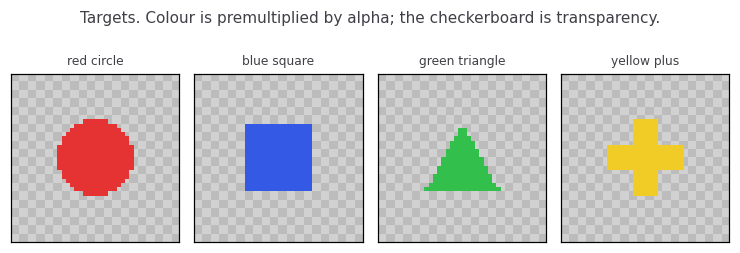

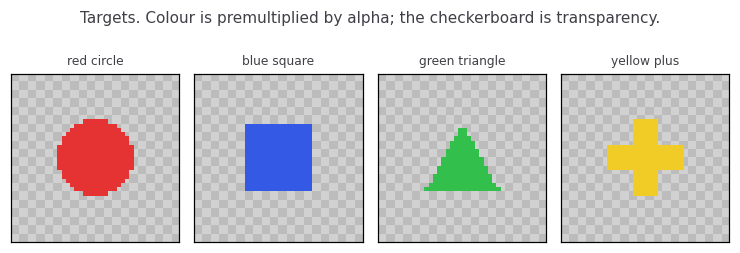

In [5]:
TARGETS, NAMES = targets_from_shapes(CFG)
## TARGETS, NAMES = targets_from_folder("./my_targets", CFG)
## TARGETS, NAMES = targets_from_emoji(["\U0001F98E", "\U0001F338", "\U0001F344", "\U0001F41F"], CFG)

TARGETS = TARGETS.to(DEVICE)
K = TARGETS.shape[0]
assert K >= 2, "a manifold needs at least two latents to interpolate between"
print(f"K = {K} targets, tensor {tuple(TARGETS.shape)}")
print("names:", NAMES)

tile_figure([TARGETS[i] for i in range(K)], ncols=min(K, 8), titles=NAMES,
            suptitle="Targets. Colour is premultiplied by alpha; the checkerboard is transparency.")

## The model

`ManifoldNCA` holds three things:

1. **`latents`** — one free embedding per target, optimised jointly with everything else.
   There is no encoder; for a fixed target set the latents are auto-decoded, DeepSDF style.
2. **`dna_decoder` + `predictor`** — $D$ and $P$. The predictor is zero-initialised, so at
   step zero every latent decodes to exactly the base rule and training begins from one
   shared, well-conditioned automaton.
3. **`base_w1 / base_b1 / base_w2`** — that base rule. Generated weights are a residual on it.

Two details in `forward` that are easy to get wrong:

- Padding is **replicate**, not circular. On a torus a boundary signal wraps around and
  the organism corrupts itself from the far edge.
- The stochastic fire mask is one mask **per cell, shared across channels**, and it is
  active in eval as well as train. Asynchrony is part of the model, not a regulariser —
  turning it off at eval time changes the dynamics.

In [6]:
class ManifoldNCA(nn.Module):
    '''An NCA whose per-cell update weights are generated from a latent.

    kappa(e) = P(D(e)), computed once per rollout. Each latent is therefore a different
    cellular automaton rather than a different input to the same one.
    '''

    def __init__(self, n_latents, cfg=CFG):
        super().__init__()
        self.cfg, self.n_latents = cfg, n_latents

        ## the genome: one free embedding per target
        self.latents = nn.Parameter(torch.randn(n_latents, cfg.latent_dim) * 0.1)

        ## DNA decoder D, then parameter predictor P -- P emits EVERY update-net weight
        self.n_generated = cfg.hidden * cfg.perception + cfg.hidden + cfg.channels * cfg.hidden
        self.dna_decoder = nn.Sequential(nn.Linear(cfg.latent_dim, cfg.dna_hidden), nn.ReLU())
        self.predictor = nn.Linear(cfg.dna_hidden, self.n_generated)
        nn.init.zeros_(self.predictor.weight)   ## start as a zero residual, so every
        nn.init.zeros_(self.predictor.bias)     ## latent begins life as the base rule

        ## the base rule the generated weights are a residual on
        self.base_w1 = nn.Parameter(torch.randn(cfg.hidden, cfg.perception) * 0.001)
        self.base_b1 = nn.Parameter(torch.zeros(cfg.hidden))
        self.base_w2 = nn.Parameter(torch.zeros(cfg.channels, cfg.hidden))

        ## Euler timestep, in log space so it cannot go negative
        self.log_leak = nn.Parameter(torch.tensor(math.log(cfg.leak_init)),
                                     requires_grad=cfg.learn_leak)

        ## buffers, so .to(device) carries them without an override
        sx = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]])
        sy = torch.tensor([[1.0, 2.0, 1.0], [0.0, 0.0, 0.0], [-1.0, -2.0, -1.0]])
        self.register_buffer("kx", sx.view(1, 1, 3, 3).repeat(cfg.channels, 1, 1, 1))
        self.register_buffer("ky", sy.view(1, 1, 3, 3).repeat(cfg.channels, 1, 1, 1))

    def generate_weights(self, z):
        '''(B, latent_dim) -> the update net's (w1, b1, w2), batched over B.'''
        cfg = self.cfg
        theta = self.predictor(self.dna_decoder(z))
        b, i = z.shape[0], 0
        n = cfg.hidden * cfg.perception
        w1 = self.base_w1 + theta[:, i:i + n].view(b, cfg.hidden, cfg.perception)
        i += n
        b1 = self.base_b1 + theta[:, i:i + cfg.hidden]
        i += cfg.hidden
        w2 = self.base_w2 + theta[:, i:].view(b, cfg.channels, cfg.hidden)
        return w1, b1, w2

    def perceive(self, state):
        p = F.pad(state, (1, 1, 1, 1), mode="replicate")   ## no-flux, not a torus
        gx = F.conv2d(p, self.kx, groups=self.cfg.channels)
        gy = F.conv2d(p, self.ky, groups=self.cfg.channels)
        return torch.cat([state, gx, gy], dim=1)

    def alive_mask(self, state):
        return F.max_pool2d(state[:, 3:4], 3, stride=1, padding=1) > self.cfg.alive_threshold

    def forward(self, state, weights):
        w1, b1, w2 = weights
        pre = self.alive_mask(state)

        p = self.perceive(state)
        a = torch.einsum("bop,bpij->boij", w1, p) + b1[:, :, None, None]
        if self.cfg.rms_norm:
            a = a / (a.pow(2).mean(dim=1, keepdim=True) + 1e-6).sqrt()
        ds = torch.einsum("bcv,bvij->bcij", w2, F.relu(a))

        m = (torch.rand_like(ds[:, :1]) <= self.cfg.fire_rate).to(ds.dtype)
        out = state + self.log_leak.exp() * ds * m

        return out * (pre & self.alive_mask(out)).to(out.dtype)


def new_seed(n, cfg=CFG, device=DEVICE):
    '''A single living cell in the centre. Identical for every latent -- that identity
    is what makes the latent the only explanation for the difference in outcome.'''
    s = torch.zeros(n, cfg.channels, cfg.grid, cfg.grid, device=device)
    s[:, 3, cfg.grid // 2, cfg.grid // 2] = 1.0
    return s


def rollout(model, state, weights, steps, snapshots=None):
    want = set(snapshots or ())
    snaps = {}
    for i in range(1, steps + 1):
        state = model(state, weights)
        if i in want:
            snaps[i] = state.clone()
    return state, snaps


@torch.no_grad()
def grow(model, z, steps=None, snapshots=None, seed=0):
    '''Deterministic eval rollout from an identical seed for every row of z.

    Note this reseeds the GLOBAL torch RNG so the stochastic fire mask is reproducible.
    Only call it outside the training loop.
    '''
    cfg = model.cfg
    torch.manual_seed(seed)
    state = new_seed(z.shape[0], cfg, z.device)
    return rollout(model, state, model.generate_weights(z),
                   cfg.steps_max if steps is None else steps, snapshots)

In [7]:
torch.manual_seed(CFG.seed)
model = ManifoldNCA(K, CFG).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params:,} parameters total")
print(f"the predictor emits {model.n_generated:,} update-net weights per latent")

549,729 parameters total
the predictor emits 8,320 update-net weights per latent


## Sanity checks

Run this **before** spending time on training. It costs a second and catches the things
that otherwise waste an hour.

The important ones are the gradient checks. If gradient never reaches the latents, the
latent is decoration, every latent decodes to the same rule, and the model trains happily
to a blurry average of all your targets. The shuffle-z ablation at the end of the notebook
detects that too — but only after a full training run.

There is a subtlety here worth understanding, because it looks like a bug the first time
you meet it. **At initialisation the gradient to `model.latents` is exactly zero, and that
is correct.** The predictor is zero-initialised on purpose, so $\theta = P(D(z)) = 0$ for
every $z$: the latents genuinely have no effect yet, and every one of them decodes to the
same base rule. What must be non-zero at init is the gradient to the *predictor* — the
thing that moves it off zero and brings the latents to life. So the check below asserts
that on the real model, and probes the latent path on a throwaway copy given a small
non-zero predictor.

In [8]:
def sanity_check(model, targets):
    cfg, k = model.cfg, model.n_latents
    dev = model.latents.device

    if targets.shape != (k, 4, cfg.grid, cfg.grid):
        raise AssertionError(
            f"targets are {tuple(targets.shape)} but the model expects "
            f"{(k, 4, cfg.grid, cfg.grid)} -- did CFG.grid change after loading targets?")

    w1, b1, w2 = model.generate_weights(model.latents)
    assert w1.shape == (k, cfg.hidden, cfg.perception), w1.shape
    assert b1.shape == (k, cfg.hidden), b1.shape
    assert w2.shape == (k, cfg.channels, cfg.hidden), w2.shape

    state = new_seed(k, cfg, dev)
    out = model(state, (w1, b1, w2))
    assert out.shape == state.shape, f"{out.shape} != {state.shape}"
    assert torch.isfinite(out).all(), "non-finite values after a single step"

    final, _ = rollout(model, new_seed(k, cfg, dev), (w1, b1, w2), 8)
    loss = F.mse_loss(final[:, 0:4], targets)
    g_pred = torch.autograd.grad(loss, model.predictor.weight)[0].norm().item()
    if not (math.isfinite(g_pred) and g_pred > 0):
        raise AssertionError(
            f"gradient to the predictor has norm {g_pred} -- nothing can ever move it off "
            f"its zero init, so every latent will decode to the base rule forever")

    ## The latent path has to be probed on a copy. On the real model at initialisation the
    ## predictor is deliberately all zeros, so d(theta)/dz is exactly zero and the latent
    ## gradient is legitimately 0.0 -- every latent decodes to the base rule and there is
    ## nothing yet to tell them apart. Once the predictor moves off zero (which the check
    ## above guarantees it can) the latents become connected. Give the probe a small
    ## non-zero predictor to test that connection now rather than 100 epochs from now.
    probe = copy.deepcopy(model)
    nn.init.normal_(probe.predictor.weight, std=1e-3)
    p_final, _ = rollout(probe, new_seed(k, cfg, dev),
                         probe.generate_weights(probe.latents), 8)
    g_lat = torch.autograd.grad(F.mse_loss(p_final[:, 0:4], targets),
                                probe.latents)[0].norm().item()
    if not (math.isfinite(g_lat) and g_lat > 0):
        raise AssertionError(
            f"gradient to latents has norm {g_lat} even with a non-zero predictor -- z is "
            f"not connected to the loss, so it cannot differentiate the automata")

    alive = model.alive_mask(final).sum(dim=(1, 2, 3)).float()
    print(f"  weight shapes        w1 {tuple(w1.shape)}  b1 {tuple(b1.shape)}  w2 {tuple(w2.shape)}")
    print(f"  one step             finite, shape preserved {tuple(out.shape)}")
    print(f"  after 8 steps        loss {loss.item():.5f}, alive cells per latent "
          f"{[int(v) for v in alive.tolist()]}")
    print(f"  grad -> predictor    {g_pred:.3e}   (must be > 0 at init)")
    print(f"  grad -> latents      {g_lat:.3e}   (probe copy, must be > 0)")
    print(f"  leak exp(rho)        {model.log_leak.exp().item():.4f} "
          f"({'learnable' if model.log_leak.requires_grad else 'frozen'})")
    print("all checks passed")


sanity_check(model, TARGETS)

  weight shapes        w1 (4, 128, 48)  b1 (4, 128)  w2 (4, 16, 128)
  one step             finite, shape preserved (4, 16, 40, 40)
  after 8 steps        loss 0.06589, alive cells per latent [9, 9, 9, 9]
  grad -> predictor    1.615e-05   (must be > 0 at init)
  grad -> latents      4.604e-08   (probe copy, must be > 0)
  leak exp(rho)        0.1000 (learnable)
all checks passed


## Training

One sample per latent per epoch, all from identical seeds, rolled out for a random number
of steps in `[steps_min, steps_max]` so the organism cannot learn to be correct at exactly
one moment.

Two details that are load-bearing:

- **Per-parameter gradient normalisation, with scalars excluded.** Normalising each
  parameter's gradient by its own norm stabilises NCA training, but for a *scalar*
  parameter that operation yields exactly $\pm 1$ every single step — a fixed-size random
  walk rather than a gradient. Scalars go in their own optimiser group at a low fixed rate.
- **Best-checkpoint tracking.** The loss is noisy because the rollout length and the fire
  mask are both random; the final epoch is not reliably the best one.

The left plot is total loss on a log scale. The right is current MSE per latent, so you
can see a single target failing while the average looks fine.

In [9]:
def _training_plot(history, per_latent, names, epoch, best, elapsed, leak):
    clear_output(wait=True)
    fig, (ax_l, ax_p) = plt.subplots(1, 2, figsize=(11, 3.4),
                                     gridspec_kw={"width_ratios": [2, 1]})

    ax_l.plot(history["epoch"], history["loss"], color=SERIES, linewidth=2)
    ax_l.set_yscale("log")
    ax_l.set_xlabel("epoch")
    ax_l.set_ylabel("MSE, log scale")
    ax_l.set_title(f"loss {history['loss'][-1]:.6f}    best {best:.6f}", loc="left", color=INK)

    y = np.arange(len(per_latent))
    ax_p.barh(y, np.maximum(per_latent.numpy(), 1e-9), color=SERIES, height=0.62)
    ax_p.set_yticks(y)
    ax_p.set_yticklabels([n if len(n) <= 14 else n[:13] + "\u2026" for n in names], fontsize=8)
    ax_p.invert_yaxis()
    ax_p.set_xscale("log")
    ax_p.set_xlabel("per-latent MSE, log scale")
    ax_p.set_title(f"epoch {epoch}    {elapsed:.0f}s    leak {leak:.3f}", loc="left", color=INK)

    for ax, axis in ((ax_l, "both"), (ax_p, "x")):
        ax.grid(True, axis=axis, color=GRIDLINE, linewidth=0.8)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_color(GRIDLINE)
        ax.tick_params(colors=INK_MUTED, labelsize=8)
    fig.tight_layout()
    plt.show()


def train(model, targets, names, cfg=None, live=True):
    cfg = cfg or model.cfg
    k = model.n_latents

    ## scalars must NOT go through per-parameter gradient normalisation
    vec = [p for p in model.parameters() if p.numel() > 1]
    sca = [p for p in model.parameters() if p.numel() == 1 and p.requires_grad]
    opt = torch.optim.Adam([{"params": vec, "lr": cfg.lr},
                            {"params": sca, "lr": cfg.scalar_lr}])

    history = {"epoch": [], "loss": []}
    best, best_state = float("inf"), copy.deepcopy(model.state_dict())
    per = torch.zeros(k)
    t0 = time.time()

    for epoch in range(cfg.epochs):
        frac = epoch / max(cfg.epochs - 1, 1)
        opt.param_groups[0]["lr"] = cfg.lr * (0.05 + 0.95 * 0.5 * (1 + math.cos(math.pi * frac)))

        opt.zero_grad()
        state = new_seed(k, cfg, targets.device)
        weights = model.generate_weights(model.latents)
        steps = int(torch.randint(cfg.steps_min, cfg.steps_max + 1, (1,)).item())
        state, _ = rollout(model, state, weights, steps)

        loss = F.mse_loss(state[:, 0:4], targets)
        loss.backward()
        for p in vec:
            if p.grad is not None:
                p.grad /= p.grad.norm() + 1e-8
        opt.step()

        history["epoch"].append(epoch)
        history["loss"].append(loss.item())
        if loss.item() < best:
            best, best_state = loss.item(), copy.deepcopy(model.state_dict())

        if epoch % cfg.log_every == 0 or epoch == cfg.epochs - 1:
            with torch.no_grad():
                per = (state[:, 0:4] - targets).pow(2).mean(dim=(1, 2, 3)).cpu()
            if live:
                _training_plot(history, per, names, epoch, best,
                               time.time() - t0, model.log_leak.exp().item())

    model.load_state_dict(best_state)      ## the last epoch is not reliably the best one
    print(f"done in {time.time() - t0:.1f}s | best loss {best:.6f} | weights restored to best")
    return history

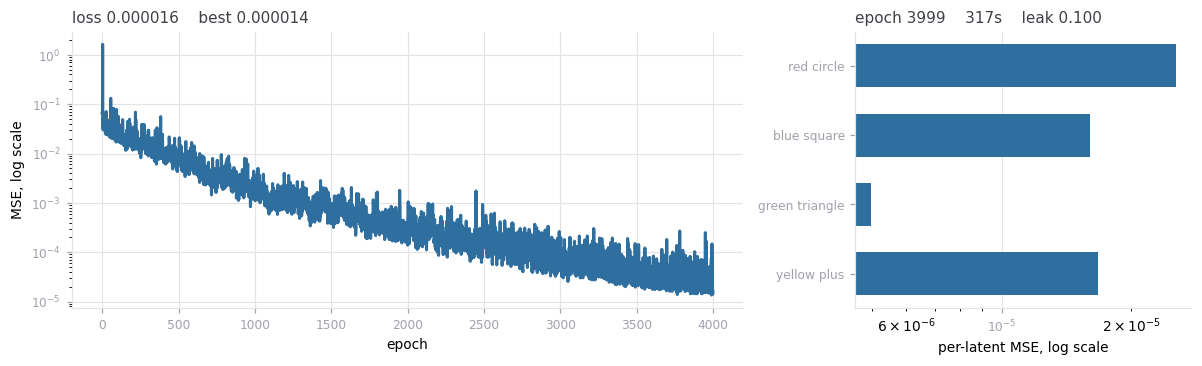

done in 317.0s | best loss 0.000014 | weights restored to best


In [10]:
history = train(model, TARGETS, NAMES, CFG)

## Verification — the shuffle-z ablation

This is the acceptance test, and it is the only cell whose result decides whether you
built a manifold or an expensive average.

Roll the latents by one position and re-grow. Latent `z1`'s rule now has to produce
target 0, `z2`'s has to produce target 1, and so on. If the latent genuinely selects the
automaton, this is catastrophic. If shuffling barely changes the loss, every latent
decoded to roughly the same rule and the latent space is decoration.

The reference prototype measured **2663x worse** on four synthetic shapes. Anything in
the hundreds or above is a real manifold; a ratio near 1 means it failed.

In [11]:
@torch.no_grad()
def shuffle_z_ablation(model, targets, steps=None, shift=1):
    k = model.n_latents
    perm = torch.roll(torch.arange(k, device=targets.device), shifts=shift)
    ok, _ = grow(model, model.latents, steps)
    sh, _ = grow(model, model.latents[perm], steps)
    l_ok = F.mse_loss(ok[:, 0:4], targets).item()
    l_sh = F.mse_loss(sh[:, 0:4], targets).item()
    return {
        "correct": l_ok,
        "shuffled": l_sh,
        "ratio": l_sh / max(l_ok, 1e-12),
        "per_latent": (ok[:, 0:4] - targets).pow(2).mean(dim=(1, 2, 3)).cpu(),
        "correct_state": ok,
        "shuffled_state": sh,
    }


ABLATION = shuffle_z_ablation(model, TARGETS)
print(f"correct z  {ABLATION['correct']:.6f}")
print(f"shuffled z {ABLATION['shuffled']:.6f}")
print(f"ratio      {ABLATION['ratio']:.1f}x worse\n")
for i, n in enumerate(NAMES):
    print(f"  z{i}  {n:<18} MSE {ABLATION['per_latent'][i].item():.6f}")

if ABLATION["ratio"] < 10:
    print("\nWARNING: shuffling the latent is nearly free. The latent is not selecting "
          "the automaton -- train longer, or raise latent_dim / dna_hidden.")

correct z  0.000020
shuffled z 0.046209
ratio      2350.2x worse

  z0  red circle         MSE 0.000027
  z1  blue square        MSE 0.000013
  z2  green triangle     MSE 0.000022
  z3  yellow plus        MSE 0.000018


## Figures

Four figures, each answering a different question:

| figure | question |
|---|---|
| growth | Does the latent alone decide what grows? |
| interpolation | Is the latent space actually *continuous* — i.e. a manifold? |
| ablation | Is the latent load-bearing, or decoration? |
| walk (GIF) | What does moving through the manifold look like? |

The interpolation figure is the one that earns the word *manifold*. Its corners are
trained latents; every interior tile is a rule generated from a latent that was never
trained on anything. If those interpolate smoothly instead of snapping between the
nearest trained shapes, the space between the targets is real.

In [12]:
def lerp_path(z, order, per_leg):
    '''Piecewise-linear walk through latents in `order`, per_leg samples per segment.'''
    pts = []
    for a, b in zip(order[:-1], order[1:]):
        for t in torch.linspace(0, 1, per_leg + 1, device=z.device)[:-1]:
            pts.append((1 - t) * z[a] + t * z[b])
    pts.append(z[order[-1]])
    return torch.stack(pts)


def figure_growth(model, targets, names, steps=None, path=None):
    cfg = model.cfg
    steps = steps or sorted({max(1, int(cfg.steps_max * f))
                             for f in (0.12, 0.3, 0.45, 0.6, 0.8, 1.0)})
    _, snaps = grow(model, model.latents, max(steps), snapshots=steps)

    images, titles = [], []
    for r in range(model.n_latents):
        for s in steps:
            images.append(snaps[s][r])
            titles.append(f"step {s}" if r == 0 else "")
        images.append(targets[r])
        titles.append("target" if r == 0 else "")

    return tile_figure(
        images, ncols=len(steps) + 1, titles=titles,
        row_labels=[f"z{i}\n{n}" for i, n in enumerate(names)],
        suptitle="One NCA, one seed, K latents. The latent is decoded into the update rule's\n"
                 "WEIGHTS, so each row is a different cellular automaton -- nothing else differs.",
        path=path)


def figure_interpolation(model, names, corners=None, n=7, path=None):
    z = model.latents.detach()
    k = z.shape[0]

    if k >= 4:
        c = tuple(corners) if corners else (0, 1, 2, 3)
        u = torch.linspace(0, 1, n, device=z.device)
        zs = torch.stack([(1 - v) * ((1 - a) * z[c[0]] + a * z[c[1]])
                          + v * ((1 - a) * z[c[2]] + a * z[c[3]])
                          for v in u for a in u])
        final, _ = grow(model, zs)
        corner_pos = [0, n - 1, n * (n - 1), n * n - 1]
        titles = [""] * (n * n)
        for pos, ci in zip(corner_pos, c):
            titles[pos] = names[ci]
        return tile_figure(
            [final[i] for i in range(n * n)], ncols=n, titles=titles,
            highlight=set(corner_pos), scale=4, tile_in=1.35,
            suptitle="A 2D slice of the manifold. Corners are TRAINED latents (red).\n"
                     "Every interior tile is a rule generated from a latent that was never "
                     "trained --\nif the space is a manifold, these interpolate rather than snap.",
            path=path)

    ## Fewer than four latents: a 1D strip instead of a 2D patch. One full row per leg,
    ## trained latents at both ends of every row -- a single wrapped path would leave a
    ## ragged trailing row and put the labels in arbitrary places.
    u = torch.linspace(0, 1, n, device=z.device)
    zs = torch.stack([(1 - t) * z[a] + t * z[a + 1] for a in range(k - 1) for t in u])
    final, _ = grow(model, zs)
    titles, highlight = [""] * zs.shape[0], set()
    for r in range(k - 1):
        titles[r * n], titles[r * n + n - 1] = names[r], names[r + 1]
        highlight |= {r * n, r * n + n - 1}
    return tile_figure(
        [final[i] for i in range(zs.shape[0])], ncols=n, titles=titles,
        highlight=highlight, scale=4, tile_in=1.35,
        suptitle=f"1D slices of the manifold ({k} latents, red = trained), one row per pair.\n"
                 "Every unlabelled tile is a rule generated from a latent that was never trained.",
        path=path)


def figure_ablation(model, targets, names, result=None, path=None):
    r = result or shuffle_z_ablation(model, targets)
    k = model.n_latents
    images = [r["correct_state"][i] for i in range(k)] + [r["shuffled_state"][i] for i in range(k)]
    titles = [f"target: {n}" for n in names] + [""] * k
    return tile_figure(
        images, ncols=k, titles=titles, row_labels=["correct z", "shuffled z"],
        suptitle=f"Shuffle-z ablation. MSE {r['correct']:.5f} -> {r['shuffled']:.5f} "
                 f"({r['ratio']:.0f}x worse).\nIf the bottom row still matched its column, "
                 f"the latent would be decoration.",
        path=path)


def figure_walk_gif(model, order=None, per_leg=14, scale=6, duration=90, path=None):
    z = model.latents.detach()
    order = order if order is not None else list(range(z.shape[0])) + [0]   ## closed loop
    zs = lerp_path(z, order, per_leg)
    final, _ = grow(model, zs)
    frames = [Image.fromarray((upscale(composite(final[i]), scale) * 255).astype(np.uint8))
              for i in range(zs.shape[0])]
    path = path or os.path.join(model.cfg.out_dir, "manifold_walk.gif")
    frames[0].save(path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    print(f"saved {path} ({len(frames)} frames)")
    display(IPyImage(filename=path))
    return path

saved outputs\manifold_growth.png


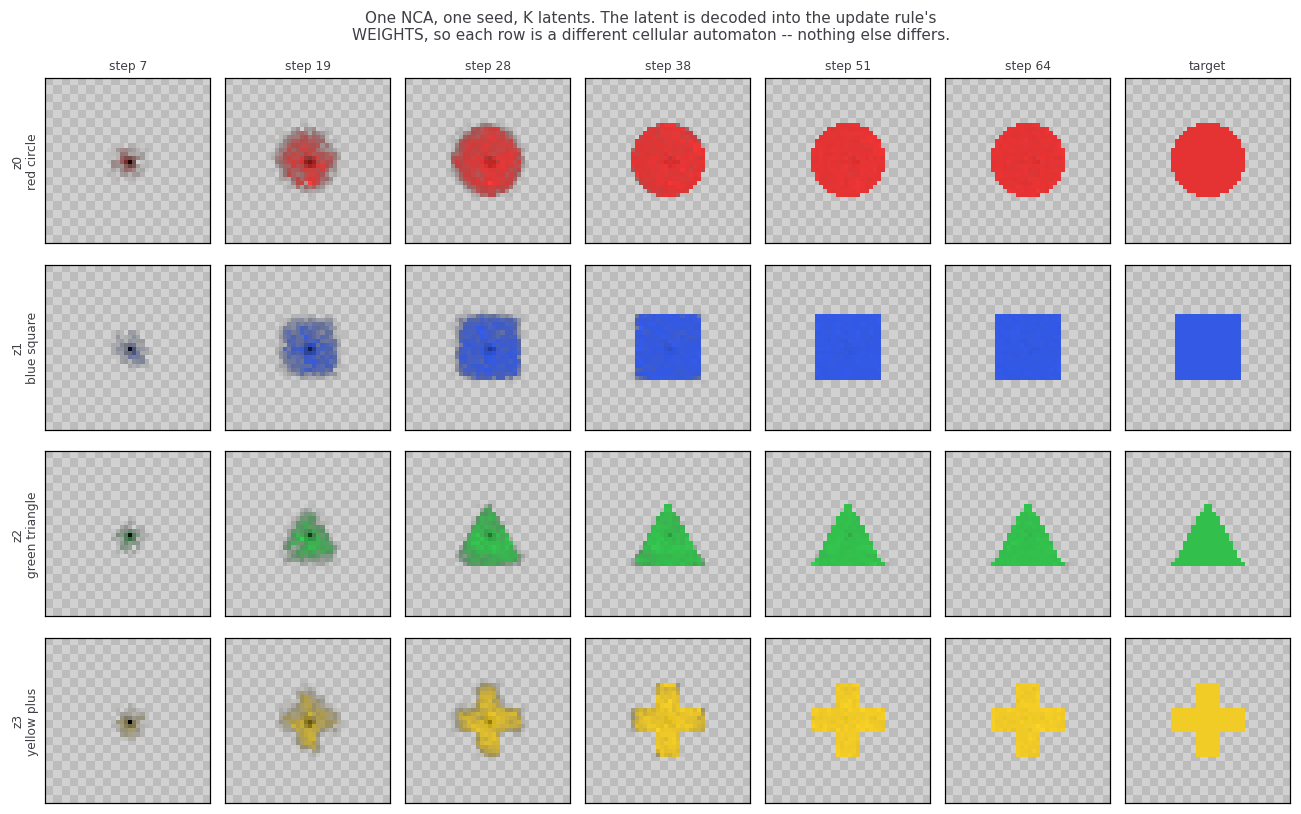

In [13]:
figure_growth(model, TARGETS, NAMES, path=os.path.join(CFG.out_dir, "manifold_growth.png"));

saved outputs\manifold_interp.png


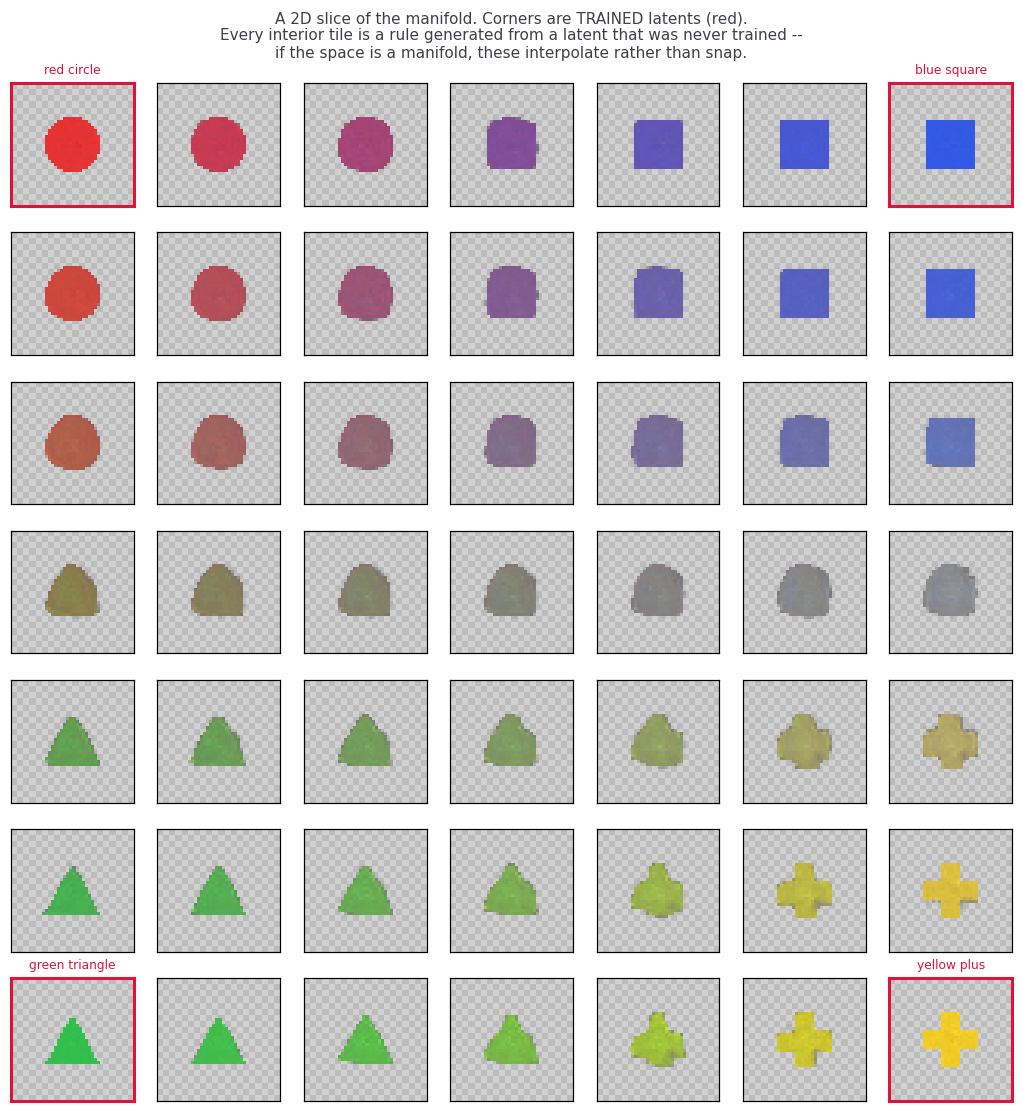

In [14]:
## `corners=` picks which four latents sit at the corners of the 2D slice.
figure_interpolation(model, NAMES, corners=None, n=7,
                     path=os.path.join(CFG.out_dir, "manifold_interp.png"));

saved outputs\manifold_ablation.png


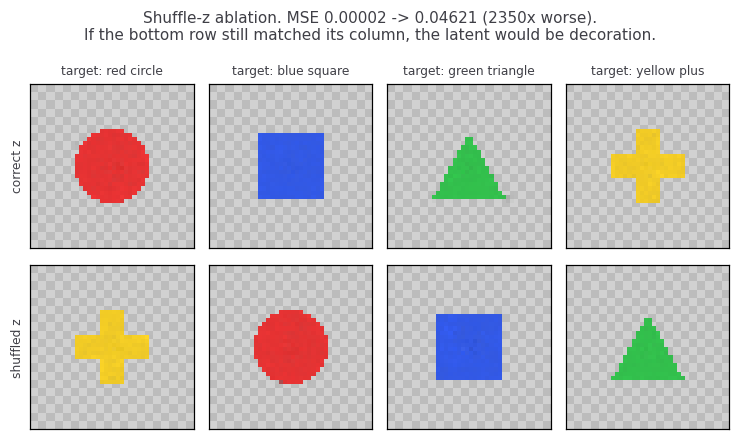

In [15]:
figure_ablation(model, TARGETS, NAMES, result=ABLATION,
                path=os.path.join(CFG.out_dir, "manifold_ablation.png"));

saved outputs\manifold_walk.gif (57 frames)


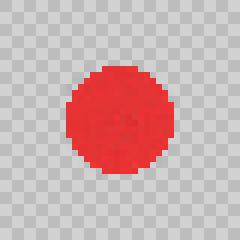

In [16]:
figure_walk_gif(model, per_leg=14);

## Save and load

The checkpoint carries the config, so a reload rebuilds an identically-shaped model
without you having to remember what `latent_dim` was when you trained it.

In [17]:
def save_checkpoint(model, names, path=None):
    path = path or os.path.join(model.cfg.out_dir, model.cfg.ckpt_name)
    torch.save({"state_dict": model.state_dict(), "names": names,
                "config": asdict(model.cfg), "n_latents": model.n_latents}, path)
    print(f"saved {path}")
    return path


def load_checkpoint(path, device=DEVICE):
    ck = torch.load(path, map_location=device, weights_only=False)
    cfg = Config(**ck["config"])
    m = ManifoldNCA(ck["n_latents"], cfg).to(device)
    m.load_state_dict(ck["state_dict"])
    m.eval()
    return m, ck["names"], cfg


CKPT = save_checkpoint(model, NAMES)

saved outputs\manifold.pth


In [18]:
## Round-trip check: reload and confirm the ablation reproduces.
reloaded, reloaded_names, reloaded_cfg = load_checkpoint(CKPT)
check = shuffle_z_ablation(reloaded, TARGETS)
print(f"reloaded {reloaded.n_latents} latents: {reloaded_names}")
print(f"correct {check['correct']:.6f} -> shuffled {check['shuffled']:.6f} "
      f"({check['ratio']:.1f}x)")

reloaded 4 latents: ['red circle', 'blue square', 'green triangle', 'yellow plus']
correct 0.000020 -> shuffled 0.046209 (2350.2x)


## Recipe: train a manifold on your own targets

1. Put your images in a folder. **PNGs with real transparency work far better than JPEGs** —
   the alive-mask needs a shape to find, and a fully opaque image is just a filled square.
2. In *Choose your targets*, switch to `targets_from_folder("./your_folder", CFG)`.
3. Run *Sanity checks*. If gradient reaches `model.latents`, the wiring is fine.
4. Run *Training*. Watch the per-latent bars, not just the total loss — one target
   lagging while the rest converge means the latent space is too small.
5. Run the *shuffle-z ablation*. That number is the result.

### When it does not work

| symptom | cause | fix |
|---|---|---|
| ablation ratio near 1 | latents all decode to the same rule | raise `latent_dim` and `dna_hidden`; train longer |
| every organism dies out | the alive-mask killed the seed before growth started | lower `alive_threshold`, or raise `leak_init` |
| loss plateaus high, shapes are blurry | too many targets for the capacity | raise `hidden`, or use fewer targets |
| interpolation snaps between trained shapes | latent space is discretised, not continuous | more epochs; consider a small penalty on `latents.norm()` |
| targets look like filled squares in the preview | your images have no alpha channel | use PNGs with transparency |

Grids larger than `40` cost roughly quadratic time per step. Start at 40 and confirm the
ablation is healthy before scaling up.

### What this does not do

The organisms here are **static shapes**, evaluated at around `steps_max`. There is no
sample pool and no persistence objective, so nothing guarantees a shape holds together at
step 500. That is a deliberate scope boundary, matching the prototype this was built from.